## 5.0 — Setup & load 3 phiên bản dữ liệu

In [15]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "/kaggle/working"  # đổi lại nếu chạy ở nơi khác

FEATURE_COLS = [
    "distance_to_goal", "angle_to_goal", "n_opponents_in_frame", "n_teammates_in_frame",
    "under_pressure", "body_part_Head", "body_part_Left Foot", "body_part_Other", "body_part_Right Foot",
]

raw_frames = {
    "Unscaled": pd.read_csv(f"{DATA_DIR}/X_unscaled.csv", encoding="utf-8-sig"),
    "StandardScaler": pd.read_csv(f"{DATA_DIR}/X_standard_scaled.csv", encoding="utf-8-sig"),
    "RobustScaler": pd.read_csv(f"{DATA_DIR}/X_robust_scaled.csv", encoding="utf-8-sig"),
}

# ID dùng chung (thứ tự dòng giống nhau ở cả 3 file, đã đảm bảo từ Task 4)
id_df = raw_frames["Unscaled"][["event_id", "match_id", "season_id", "team_name", "player_name"]].copy()

X_versions = {name: df[FEATURE_COLS].values for name, df in raw_frames.items()}
for name, X in X_versions.items():
    print(name, X.shape)


Unscaled (3200, 9)
StandardScaler (3200, 9)
RobustScaler (3200, 9)


## 5.1 — Elbow Method (song song 3 phiên bản)

Chạy K-Means với `k = 2..10`, ghi lại `inertia_` (WCSS — within-cluster sum of squares) cho mỗi phiên bản. "Điểm khuỷu tay" được xác định tự động bằng **kneedle heuristic** đơn giản: chuẩn hóa trục k và inertia về [0,1], tìm điểm có khoảng cách vuông góc lớn nhất tới đường thẳng nối điểm đầu-cuối.

In [16]:
K_RANGE = list(range(2, 11))


def kneedle_elbow(k_values, values):
    k = np.array(k_values, dtype=float)
    y = np.array(values, dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    x1, y1 = k_norm[0], y_norm[0]
    x2, y2 = k_norm[-1], y_norm[-1]
    num = np.abs((y2 - y1) * k_norm - (x2 - x1) * y_norm + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    idx = np.argmax(dist)
    return int(k[idx])


inertia_results = {}
for name, X in X_versions.items():
    inertias = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    inertia_results[name] = inertias

elbow_k = {name: kneedle_elbow(K_RANGE, vals) for name, vals in inertia_results.items()}
print("Elbow k (kneedle) theo từng phiên bản:", elbow_k)


Elbow k (kneedle) theo từng phiên bản: {'Unscaled': 5, 'StandardScaler': 5, 'RobustScaler': 5}


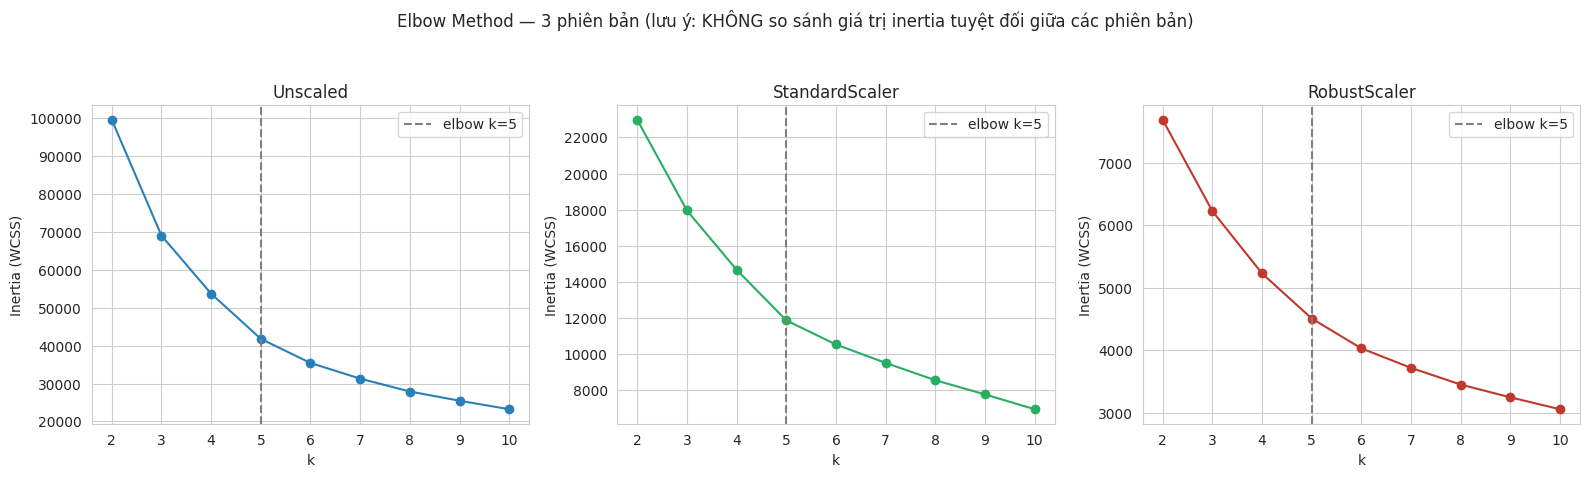

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
colors = {"Unscaled": "#2980b9", "StandardScaler": "#27ae60", "RobustScaler": "#c0392b"}

for ax, name in zip(axes, X_versions.keys()):
    ax.plot(K_RANGE, inertia_results[name], marker="o", color=colors[name])
    ax.axvline(elbow_k[name], linestyle="--", color="gray", label=f"elbow k={elbow_k[name]}")
    ax.set_title(name)
    ax.set_xlabel("k")
    ax.set_ylabel("Inertia (WCSS)")
    ax.legend()

plt.suptitle("Elbow Method — 3 phiên bản (lưu ý: KHÔNG so sánh giá trị inertia tuyệt đối giữa các phiên bản)", y=1.05)
plt.tight_layout()
plt.show()


**Lưu ý quan trọng:** trục tung (inertia) của 3 subplot có **thang đo hoàn toàn khác nhau** (Unscaled tính bằng đơn vị mét² do `distance_to_goal` chi phối, 2 phiên bản kia tính trên đơn vị đã chuẩn hóa) — vì vậy **không so sánh giá trị inertia tuyệt đối giữa các phiên bản**, chỉ so sánh **hình dạng đường cong** (vị trí khuỷu tay) trong nội bộ từng phiên bản.

## 5.2 — Silhouette Score (song song 3 phiên bản)

In [18]:
silhouette_results = {}
for name, X in X_versions.items():
    sils = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    silhouette_results[name] = sils

best_k_silhouette = {name: K_RANGE[int(np.argmax(vals))] for name, vals in silhouette_results.items()}
print("Best k theo Silhouette:", best_k_silhouette)


Best k theo Silhouette: {'Unscaled': 2, 'StandardScaler': 4, 'RobustScaler': 2}


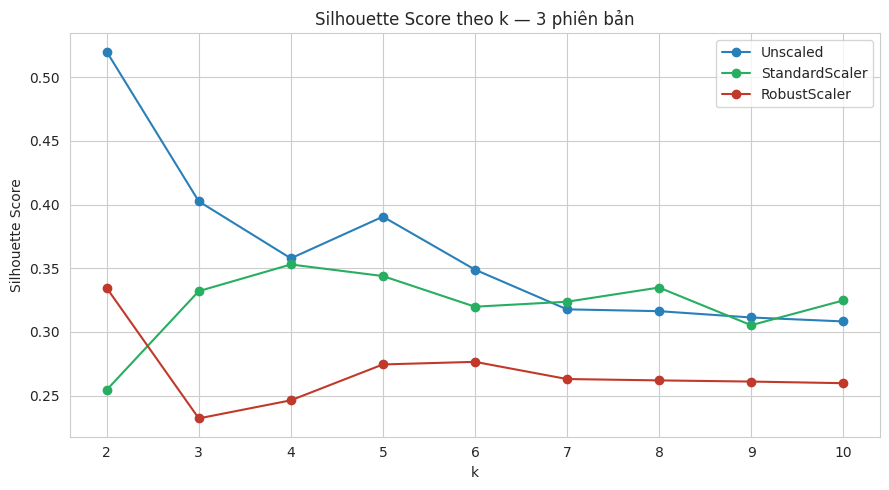

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in silhouette_results.items():
    ax.plot(K_RANGE, vals, marker="o", label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score theo k — 3 phiên bản")
ax.legend()
plt.tight_layout()
plt.show()


**Lưu ý quan trọng (dễ hiểu nhầm nhất trong bước này):** Silhouette Score của `Unscaled` có vẻ **cao hơn hẳn** 2 phiên bản còn lại ở k nhỏ — nhưng điều này **không có nghĩa là clustering trên Unscaled "tốt hơn"**. Vì `distance_to_goal` có scale (đơn vị mét, range ~70) áp đảo hoàn toàn các feature khác (range 0-1) trong không gian Unscaled, K-Means gần như chỉ đang phân cụm dựa theo 1 biến duy nhất — silhouette cao chỉ phản ánh việc "dễ tách theo 1 trục" chứ không phải mô hình đã học được cấu trúc đa chiều thật sự của dữ liệu. **Silhouette chỉ nên so sánh nội bộ trong cùng 1 phiên bản** (để chọn k), không dùng để so sánh "phiên bản nào tốt hơn" giữa các không gian metric khác nhau.

## 5.3 — Gap Statistic (song song 3 phiên bản)

Thuật toán Gap Statistic (Tibshirani, Walther & Hastie, 2001): với mỗi k, so sánh `log(inertia)` của dữ liệu thật với `log(inertia)` trung bình của `B` bộ dữ liệu tham chiếu ngẫu nhiên (uniform, cùng phạm vi giá trị từng feature). Chọn k nhỏ nhất thỏa `Gap(k) ≥ Gap(k+1) − s(k+1)` (quy tắc 1-standard-error).

In [20]:
def compute_gap_statistic(X, k_range, B=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)

    def fit_inertia(data, k, seed):
        km = KMeans(n_clusters=k, n_init=10, random_state=seed)
        km.fit(data)
        return km.inertia_

    gaps, sks = [], []
    for k in k_range:
        wk_real = fit_inertia(X, k, random_state)

        log_wk_refs = []
        for b in range(B):
            X_ref = rng.uniform(low=mins, high=maxs, size=X.shape)
            wk_ref = fit_inertia(X_ref, k, random_state + b + 1)
            log_wk_refs.append(np.log(wk_ref))
        log_wk_refs = np.array(log_wk_refs)

        gap = log_wk_refs.mean() - np.log(wk_real)
        sk = log_wk_refs.std() * np.sqrt(1 + 1.0 / B)
        gaps.append(gap)
        sks.append(sk)

    return np.array(gaps), np.array(sks)


def choose_k_tibshirani(k_range, gaps, sks):
    for i in range(len(k_range) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_range[i]
    return None  # không tìm được k thỏa điều kiện trong phạm vi đã thử


In [21]:
gap_results = {}
for name, X in X_versions.items():
    gaps, sks = compute_gap_statistic(X, K_RANGE, B=10, random_state=42)
    gap_results[name] = (gaps, sks)

gap_k = {name: choose_k_tibshirani(K_RANGE, gaps, sks) for name, (gaps, sks) in gap_results.items()}
print("k chọn theo Gap Statistic (quy tắc Tibshirani):", gap_k)


k chọn theo Gap Statistic (quy tắc Tibshirani): {'Unscaled': 2, 'StandardScaler': None, 'RobustScaler': 2}


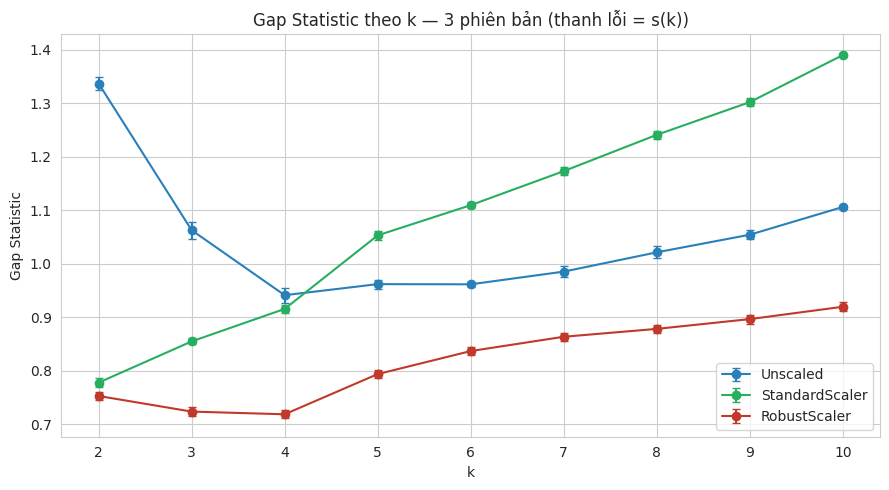

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (gaps, sks) in gap_results.items():
    ax.errorbar(K_RANGE, gaps, yerr=sks, marker="o", capsize=3, label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Gap Statistic")
ax.set_title("Gap Statistic theo k — 3 phiên bản (thanh lỗi = s(k))")
ax.legend()
plt.tight_layout()
plt.show()


**Kết quả thực tế:** `Unscaled` và `RobustScaler` đều cho Gap giảm rồi tăng trở lại, thỏa quy tắc Tibshirani sớm ở **k=2**. Riêng `StandardScaler` có Gap **tăng liên tục** trong suốt k=2→10 mà không thỏa điều kiện dừng — nghĩa là trong phạm vi k đã thử, chưa tìm được điểm gap "đủ tốt" theo quy tắc 1-SE (kết quả trả về `None`). Đây không phải lỗi code, mà là giới hạn thực tế của phương pháp: có thể k tối ưu thật sự nằm ngoài phạm vi 2-10, hoặc cấu trúc cụm của `StandardScaler` không có một "điểm gãy" rõ ràng như 2 phiên bản kia.

## 5.4 — Bảng tổng hợp: k đề xuất theo từng phương pháp × từng phiên bản

In [23]:
summary_k = pd.DataFrame({
    "Elbow (kneedle)": elbow_k,
    "Silhouette (max)": best_k_silhouette,
    "Gap Statistic (Tibshirani)": gap_k,
})
summary_k


,Elbow (kneedle),Silhouette (max),Gap Statistic (Tibshirani)
Unscaled,5,2,2.000
StandardScaler,5,4,NaN
RobustScaler,5,2,2.000


**Đọc bảng:** Elbow (kneedle) cho cùng 1 kết quả k=5 ở cả 3 phiên bản — đây là dấu hiệu cho thấy phương pháp này **ít nhạy với scaling** hơn 2 phương pháp còn lại (vì hình dạng đường cong inertia giảm dần đều khá giống nhau về mặt tương đối, dù giá trị tuyệt đối khác hẳn). Ngược lại, Silhouette và Gap Statistic **phản ứng rõ rệt với việc scaling**: `Unscaled` và `RobustScaler` nghiêng về k=2 (cấu trúc 2 nhóm rõ), còn `StandardScaler` cho kết quả khác biệt (Silhouette chọn k=4, Gap không hội tụ). Đây chính là bằng chứng cụ thể cho câu hỏi nghiên cứu ban đầu: **cách chuẩn hóa dữ liệu ảnh hưởng trực tiếp đến việc chọn k**, không phải chỉ ảnh hưởng đến hình dạng cụm.

## 5.5 — So sánh cấu trúc cụm giữa 3 phiên bản bằng Adjusted Rand Index (ARI)

Vì các phương pháp trên không đồng thuận 1 k duy nhất, cách công bằng nhất để cô lập **đúng 1 biến duy nhất đang thay đổi (cách scale)** là **cố định k** giống nhau cho cả 3 phiên bản, rồi đo ARI giữa từng cặp nhãn cụm. Lặp lại với nhiều giá trị k để xem xu hướng có ổn định không.

In [24]:
ari_k_range = [2, 3, 4, 5, 6]
ari_rows = []

cluster_labels_by_k = {}  # lưu lại để dùng ở bước sau (chọn k cuối cùng)

for k in ari_k_range:
    labels = {}
    for name, X in X_versions.items():
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels[name] = km.fit_predict(X)
    cluster_labels_by_k[k] = labels

    ari_us = adjusted_rand_score(labels["Unscaled"], labels["StandardScaler"])
    ari_ur = adjusted_rand_score(labels["Unscaled"], labels["RobustScaler"])
    ari_sr = adjusted_rand_score(labels["StandardScaler"], labels["RobustScaler"])

    ari_rows.append({
        "k": k,
        "ARI(Unscaled, StandardScaler)": ari_us,
        "ARI(Unscaled, RobustScaler)": ari_ur,
        "ARI(StandardScaler, RobustScaler)": ari_sr,
    })

ari_df = pd.DataFrame(ari_rows).set_index("k")
ari_df


,"ARI(Unscaled, StandardScaler)","ARI(Unscaled, RobustScaler)","ARI(StandardScaler, RobustScaler)"
k,,,
2,0.040,0.012,0.004
3,0.064,0.035,-0.012
4,0.097,0.258,0.190
5,0.147,0.170,0.662
6,0.167,0.153,0.654


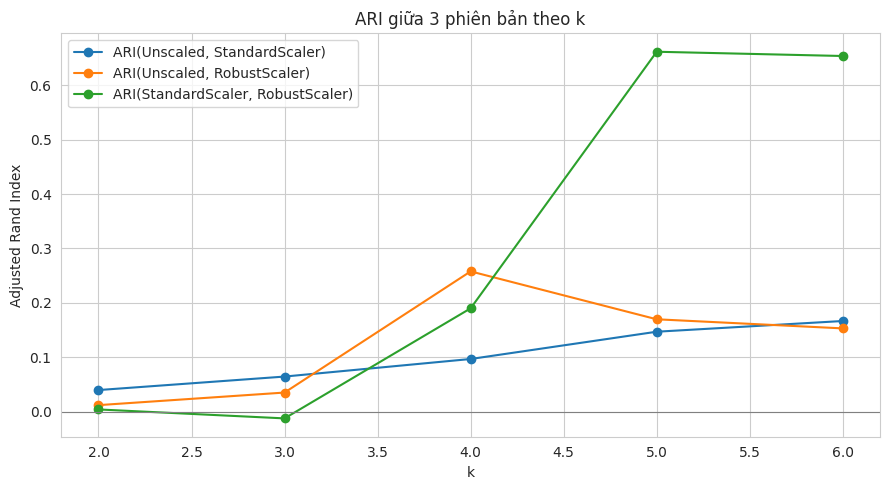

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in ari_df.columns:
    ax.plot(ari_df.index, ari_df[col], marker="o", label=col)
ax.set_xlabel("k")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("ARI giữa 3 phiên bản theo k")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


**Phát hiện quan trọng nhất của toàn bộ Task 5:**

- Ở **k=2, k=3**: cả 3 cặp ARI đều rất thấp (gần 0) — nghĩa là ở k nhỏ, **3 phiên bản cho ra 3 cách chia cụm gần như không liên quan gì đến nhau**. Scaling ảnh hưởng cực mạnh đến cấu trúc cụm khi số cụm ít.
- Ở **k=5, k=6**: `ARI(StandardScaler, RobustScaler)` tăng vọt lên khoảng **0.65** — hai phiên bản **đã scale** bắt đầu hội tụ về cùng 1 cấu trúc cụm khá giống nhau. Trong khi đó `ARI(Unscaled, StandardScaler)` và `ARI(Unscaled, RobustScaler)` vẫn ở mức thấp (~0.15-0.17) **xuyên suốt mọi giá trị k**.
- **Kết luận:** `Unscaled` luôn cho ra cấu trúc cụm khác biệt rõ rệt so với cả 2 phiên bản đã scale, ở mọi k đã thử — đây là bằng chứng thực nghiệm mạnh cho việc **bắt buộc phải scale dữ liệu** trước khi đưa vào K-Means với bộ feature có scale chênh lệch lớn như trong bài toán này. Giữa 2 cách scale, `StandardScaler` và `RobustScaler` tương đối "đồng thuận" với nhau hơn khi k đủ lớn (≥5).

## 5.6 — Chốt phương án cho Task 6

**Chọn scaler:** giữa `StandardScaler` và `RobustScaler`, chọn **RobustScaler** làm phiên bản chính thức mang sang Task 6, vì 2 lý do có căn cứ:
1. Task 4 đã cho thấy `StandardScaler` phóng đại bất thường cột one-hot hiếm (`body_part_Other`, giá trị 1 bị đẩy lên ≈10.8) — trong khi `RobustScaler` xử lý ổn định trường hợp này.
2. Ở k≥5, `RobustScaler` vẫn cho cấu trúc cụm khá tương đồng với `StandardScaler` (ARI≈0.65) — nghĩa là chọn `RobustScaler` không đánh đổi nhiều so với `StandardScaler`, nhưng an toàn hơn trước outlier/cột mất cân bằng.

**Chọn k:** dùng **k=5** — được Elbow (kneedle) đề xuất đồng nhất ở cả 3 phiên bản, đồng thời là vùng k mà 2 phiên bản đã scale bắt đầu hội tụ mạnh (ARI cao) trong bước 5.5.

In [26]:
FINAL_SCALER = "RobustScaler"
FINAL_K = 5

final_km = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
final_labels = final_km.fit_predict(X_versions[FINAL_SCALER])

cluster_output = id_df.copy()
cluster_output["cluster_id"] = final_labels

# Đồng thời lưu lại nhãn cụm của cả 3 phiên bản tại k=5 để tham khảo/so sánh thêm ở Task 6 nếu cần
for name in X_versions:
    cluster_output[f"cluster_id_{name}"] = cluster_labels_by_k[FINAL_K][name]

cluster_output.to_csv(f"{DATA_DIR}/shot_clusters_k5.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu: {DATA_DIR}/shot_clusters_k5.csv")
cluster_output.head(5)


Đã lưu: /kaggle/working/shot_clusters_k5.csv


,event_id,match_id,season_id,team_name,player_name,cluster_id,cluster_id_Unscaled,cluster_id_StandardScaler,cluster_id_RobustScaler
0,9d2b23a7-0fde-45f1-8b6e-58fc9da4aab5,8650,3,Belgium,Kevin De Bruyne,1,2,2,1
1,ff6fee87-0f6b-461e-a5fd-e5032aa19564,8650,3,Brazil,Thiago Emiliano da Silva,2,1,1,2
2,ebeaf37c-a1be-46a4-b3bb-ae4779458734,8650,3,Belgium,Eden Hazard,2,3,1,2
3,0f142c55-8a4a-4af1-b57b-e8eba2491c4b,8650,3,Belgium,Nacer Chadli,1,2,2,1
4,06ffa199-3887-4696-b954-5ba6376cbce6,8650,3,Brazil,José Paulo Bezzera Maciel Júnior,2,1,1,2


In [27]:
cluster_output["cluster_id"].value_counts().sort_index()


cluster_id
0    699
1    996
2    820
3    539
4    146
Name: count, dtype: int64

## Kết quả Task 5

File `shot_clusters_k5.csv` chứa nhãn cụm (`cluster_id`, dựa trên `RobustScaler` + k=5, cột chính thức mang sang bước sau) cùng nhãn cụm tham khảo của cả 3 phiên bản tại k=5, kèm ID để join lại `y_hidden.csv` (outcome, statsbomb_xg) ở bước validate.

**Input cho Task 6 (KNN + Cross-Validation):** dùng `X_robust_scaled.csv` làm feature và `shot_clusters_k5.csv` (cột `cluster_id`) làm nhãn — bài toán giờ chuyển thành classification có nhãn để huấn luyện KNN và đánh giá bằng k-fold Cross-Validation.


## 5.7 — Trực quan hoá không gian: phân bố cú sút theo cụm

Vẽ vị trí thực tế (`location_x`, `location_y`, đơn vị gốc — không phải feature đã scale) của
từng cú sút, tô màu theo `cluster_id`, kèm centroid (dấu sao đen) — cho cả 3 phiên bản, giống
biểu đồ "Geographical Distribution of Shot Clusters" ở `kmeans_v1.ipynb`.

**Khác với `kmeans_v1.ipynb`:** v1 so sánh 3 nhánh ở **k khác nhau** (Robust k=6, Standard/Unscaled
k=10 — mỗi nhánh tự chọn "best k" của riêng nó), nên phần nào giống so sánh táo với cam. Ở đây
dùng chung **k=5** cho cả 3 nhánh (`cluster_labels_by_k[FINAL_K]`, đã tính sẵn ở mục 5.5) — nhất
quán với cách làm ARI phía trên: cố định k để chỉ còn đúng 1 biến thay đổi là **cách scale**.

In [ ]:
# Dac diem trung binh (don vi goc, giong "Describe Centroids physically" trong kmeans_v1.ipynb)
# cua tung cum, cho ca 3 nhanh, tai chung k=FINAL_K.
#
# Luu y: X_unscaled.csv o day KHONG chua location_x/location_y (FEATURE_COLS
# khong dua toa do tho vao model, chi dung distance_to_goal/angle_to_goal da
# suy ra). De ve bieu do dia ly o cell sau, phai join lai location_x/y tu file
# raw shot goc (Task 1) qua event_id.
RAW_CSV_CANDIDATES = [
    f"{DATA_DIR}/shots_worldcup_2018_2022_raw.csv",
    f"{DATA_DIR}/extract_feature_worldcup_2018_2022_raw.csv",
    "shots_worldcup_2018_2022_raw.csv",
    "extract_feature_worldcup_2018_2022_raw.csv",
]

location_df = None
for candidate in RAW_CSV_CANDIDATES:
    try:
        location_df = pd.read_csv(candidate, encoding="utf-8-sig")[["event_id", "location_x", "location_y"]]
        print(f"Da nap location_x/y tu: {candidate}")
        break
    except FileNotFoundError:
        continue

if location_df is None:
    raise FileNotFoundError(
        "Khong tim thay file raw shot nao trong: "
        f"{RAW_CSV_CANDIDATES}. Can file nay de lay lai location_x/location_y "
        "(khong co san trong X_unscaled.csv) - sua RAW_CSV_CANDIDATES cho dung "
        "ten file ban dang co tren Kaggle."
    )

unscaled_features_original = raw_frames["Unscaled"][["event_id"] + FEATURE_COLS].merge(
    location_df, on="event_id", how="left"
)
n_missing_loc = unscaled_features_original["location_x"].isna().sum()
if n_missing_loc > 0:
    print(f"[WARN] {n_missing_loc} shot khong join duoc location_x/y (event_id khong khop) - se bi bo qua o bieu do.")
unscaled_features_original = unscaled_features_original.drop(columns=["event_id"])

labels_at_k5 = cluster_labels_by_k[FINAL_K]  # {"Unscaled":..., "StandardScaler":..., "RobustScaler":...}

centroids_original = {}
for name, lbl in labels_at_k5.items():
    tmp = unscaled_features_original.copy()
    tmp["Cluster"] = lbl
    centroids_original[name] = tmp.groupby("Cluster").mean()
    print(f"=== {name} (k={FINAL_K}) - so shot / cum ===")
    print(pd.Series(lbl).value_counts().sort_index().to_dict())

print(f"\n--- Centroid ({FINAL_SCALER}, k={FINAL_K}) - nhanh CHINH THUC ---")
display(centroids_original[FINAL_SCALER])

In [ ]:
# Bieu do phan bo vi tri cu sut theo cum, canh nhau ca 3 nhanh (giong kmeans_v1.ipynb)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f"Geographical Distribution of Shot Clusters — 3 phien ban tai k={FINAL_K}", fontsize=15)

branch_order = ["Unscaled", "StandardScaler", "RobustScaler"]

for ax, name in zip(axes, branch_order):
    lbl = labels_at_k5[name]

    # Cac cu sut, to mau theo cluster_id
    sns.scatterplot(
        x=unscaled_features_original["location_x"],
        y=unscaled_features_original["location_y"],
        hue=lbl,
        palette="tab10",
        ax=ax,
        s=20,
        alpha=0.4,
    )

    # Centroid: dau sao den
    ax.scatter(
        x=centroids_original[name]["location_x"],
        y=centroids_original[name]["location_y"],
        color="black",
        marker="*",
        s=400,
        edgecolor="white",
        linewidth=1.5,
        label="Centroid",
    )

    # Duong bien san + vach khung thanh
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
    ax.plot([120, 120], [36, 44], color="red", linewidth=4)

    title = f"{name} (k={FINAL_K})"
    if name == FINAL_SCALER:
        title += "  <- CHINH THUC"
    ax.set_title(title)
    ax.set_xlabel("location_x")
    ax.set_ylabel("location_y")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()